# 1. Exploración de Datos (EDA)

**Proyecto Integrador ****-** **Lending Club Loan Data (2007–2020)**

## 1.1. Carga inicial y visión general

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import missingno as msno
import time

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 140)


In [2]:
t0 = time.time()
df = pd.read_csv("../data/accepted_2007_to_2018Q4.csv", engine="pyarrow", dtype_backend="pyarrow")
t1 = time.time()
print(f"Tiempo de carga con pandas (motor pyarrow): {t1-t0:.2f} s")
print(f"Dimensión: {df.shape[0]:,} filas x {df.shape[1]} columnas")


Tiempo de carga con pandas (motor pyarrow): 18.57 s
Dimensión: 2,260,701 filas x 151 columnas


Como el enunciado sugiere comparar tiempos de carga, se probó también con PySpark en un proceso aislado. Los tiempos obtenidos fueron:

| Motor | Tiempo | Detalle |
|---|---|---|
| pandas (engine=\"pyarrow\") | ~15.3 s | lectura completa, tipado automático |
| Spark (arranque de sesión) | ~30.5 s | overhead fijo de la JVM, independiente del tamaño de archivo |
| Spark (lectura \"lazy\" del CSV) | ~4.7 s | solo registra el plan, no lee todavía |
| Spark (`count()`, ejecución real) | ~3.2 s | aquí sí se materializa la lectura |

Ambos confirman **2.260.701 filas** y **151 columnas**.

`describe()` sobre las 151 columnas se guardó completo en `outputs/tables/eda/describe_full.csv` (tabla muy ancha para mostrarla entera aquí); arriba se muestran las primeras 20 columnas a modo de vista previa.

In [3]:
print(df.head(3))


         id member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  installment grade sub_grade     emp_title  \
0  68407277      None     3600.0       3600.0           3600.0   36 months     13.99       123.03     C        C4       leadman   
1  68355089      None    24700.0      24700.0          24700.0   36 months     11.99       820.28     C        C1      Engineer   
2  68341763      None    20000.0      20000.0          20000.0   60 months     10.78       432.66     B        B4  truck driver   

  emp_length  ... hardship_loan_status  orig_projected_additional_accrued_interest hardship_payoff_balance_amount  \
0  10+ years  ...                 <NA>                                        <NA>                           <NA>   
1  10+ years  ...                 <NA>                                        <NA>                           <NA>   
2  10+ years  ...                 <NA>                                        <NA>                           <NA>   

  hard

In [4]:
print(df.tail(3))


                                                       id member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  \
2260698                                          88215728      None    14000.0      14000.0          14000.0   60 months     14.49   
2260699  Total amount funded in policy code 1: 1465324575      None       <NA>         <NA>             <NA>        <NA>      <NA>   
2260700   Total amount funded in policy code 2: 521953170      None       <NA>         <NA>             <NA>        <NA>      <NA>   

         installment grade sub_grade                    emp_title emp_length  ... hardship_loan_status  \
2260698       329.33     C        C4  Customer Service Technician  10+ years  ...                 <NA>   
2260699         <NA>  <NA>      <NA>                         <NA>       <NA>  ...                 <NA>   
2260700         <NA>  <NA>      <NA>                         <NA>       <NA>  ...                 <NA>   

         orig_projected_additional_acc

In [5]:
buf_dtypes = df.dtypes.value_counts()
print("Resumen de tipos de datos (info):")
print(buf_dtypes)
print(f"\nMemoria aproximada en uso: {df.memory_usage(deep=True).sum()/1e6:.0f} MB (representación pyarrow, compacta)")


Resumen de tipos de datos (info):
double[pyarrow]    112
string[pyarrow]     38
null[pyarrow]        1
Name: count, dtype: int64



Memoria aproximada en uso: 2936 MB (representación pyarrow, compacta)


In [6]:
desc_full = df.describe(include="all").T
desc_full.to_csv("../outputs/tables/eda/describe_full.csv")
desc_full.head(20)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,2260701,2260701,68407277,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
member_id,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.0,<NA>,<NA>,<NA>,15046.931228,9190.245488,500.0,8000.0,12900.0,20000.0,40000.0
funded_amnt,2260668.0,<NA>,<NA>,<NA>,15041.664057,9188.413022,500.0,8000.0,12875.0,20000.0,40000.0
funded_amnt_inv,2260668.0,<NA>,<NA>,<NA>,15023.437745,9192.331679,0.0,8000.0,12800.0,20000.0,40000.0
term,2260668,2,36 months,1609754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int_rate,2260668.0,<NA>,<NA>,<NA>,13.092829,4.832138,5.31,9.49,12.62,15.99,30.99
installment,2260668.0,<NA>,<NA>,<NA>,445.806823,267.173535,4.93,251.65,377.99,593.32,1719.83
grade,2260668,7,B,663557,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub_grade,2260668,35,C1,145903,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1.2. Análisis unidimensional

### 1.2.1 Variable objetivo (`default`)

La variable objetivo **`default`** se construye siguiendo exactamente la indicación del enunciado de la guía de la tarea. Se asigna el valor 1 cuando **`loan_status`** es igual a “Charged Off” y 0 en cualquier otro caso.

```python
df[\"default\"] = df[\"loan_status\"].apply(lambda x: 1 if x == \"Charged Off\" else 0)
```

Sin embargo, antes de hacer esto revisamos los valores que tenía **`loan_status`** y encontramos que la variable tiene 9 categorías diferentes, no solo dos. Por lo tanto, al aplicar la regla tal cual, todo lo que no sea exactamente “Charged Off” termina siendo clasificado como 0.

Esto genera algunas situaciones que vale la pena considerar. Por ejemplo, hay 878.317 préstamos con estado “Current”, que representan cerca del 39% de los datos. Estos préstamos todavía estaban vigentes, por lo que realmente no sabemos si terminaron pagando o si eventualmente incumplieron. También quedan como 0 los préstamos que estaban “Late”, “In Grace Period” o “Default”, además de los 33 registros que no tienen información en **`loan_status`**.

Otro caso que encontramos fueron 761 préstamos con el estado “Does not meet the credit policy. Status:Charged Off”. Aunque por su descripción corresponden a préstamos que terminaron en incumplimiento, no tienen exactamente el texto “Charged Off”, así que la regla los clasifica como 0.

In [7]:
print("Categorías de loan_status:")
print(df["loan_status"].value_counts(dropna=False))

df["default"] = (df["loan_status"] == "Charged Off").fillna(False).astype("int64")

target_counts = df["default"].value_counts().sort_index()
target_pct = (df["default"].value_counts(normalize=True).sort_index()*100).round(2)
print("\nDistribución de 'default' (regla literal del enunciado):")
print(pd.DataFrame({"n": target_counts, "%": target_pct}))


Categorías de loan_status:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
<NA>                                                        33
Name: count, dtype: int64[pyarrow]

Distribución de 'default' (regla literal del enunciado):
               n      %
default                
0        1992142  88.12
1         268559  11.88


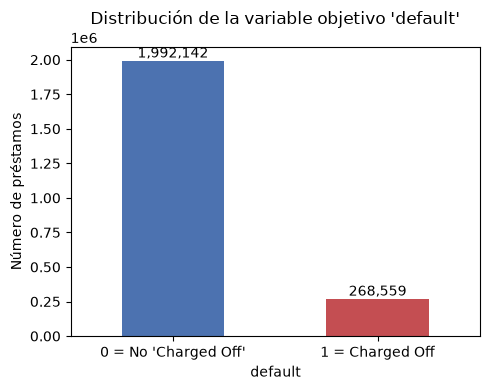

In [8]:
fig, ax = plt.subplots(figsize=(5,4))
target_counts.plot(kind="bar", ax=ax, color=["#4C72B0","#C44E52"])
ax.set_xticklabels(["0 = No 'Charged Off'","1 = Charged Off"], rotation=0)
ax.set_ylabel("Número de préstamos")
ax.set_title("Distribución de la variable objetivo 'default'")
for i,v in enumerate(target_counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/target_distribution.png", dpi=110)
plt.show()


Decidimos mantener la regla indicada en el enunciado y no modificarla, pero consideramos importante dejar registrada esta situación porque afecta la forma en que se están definiendo las clases. Más adelante retomamos esta limitación al analizar los resultados.

Después de crear la variable, vemos que existe un desbalance entre las dos clases, porque el 88,12% de los préstamos quedaron como 0 y el 11,88% como 1. Es decir, hay aproximadamente 7,4 préstamos de clase 0 por cada préstamo de clase 1.

Este desbalance hace que el accuracy por sí solo no sea suficiente para evaluar los modelos. Por eso usamos una partición estratificada y prestamos más atención a métricas como AUC-ROC, F1 y AUC-PR. También tenemos en cuenta el umbral de decisión al momento de comparar los modelos.

### 1.2.2 Variables numéricas

In [9]:
def parse_emp_length(x):
    if pd.isna(x): return np.nan
    x = str(x)
    if "10+" in x: return 10.0
    if "< 1" in x: return 0.0
    digits = "".join(ch for ch in x if ch.isdigit())
    return float(digits) if digits else np.nan

df["emp_length_num"] = df["emp_length"].apply(parse_emp_length)

numeric_vars = ["loan_amnt","int_rate","installment","annual_inc","dti",
                "fico_range_low","fico_range_high","open_acc","revol_bal",
                "revol_util","total_acc","pub_rec","delinq_2yrs","mort_acc",
                "inq_last_6mths","emp_length_num"]


Para los modelos seleccionamos un conjunto de variables numéricas que estuvieran disponibles en el momento en que se otorgó el préstamo.

Por eso dejamos por fuera variables como **`total_pymnt`**, **`recoveries`**, **`last_pymnt_d`** y **`out_prncp`**, entre otras. Estas variables contienen información que se conoce después, cuando el préstamo ya ha avanzado o incluso ha terminado. Con esto evitamos data leakage.

Al revisar las variables seleccionadas encontramos algunos casos que nos llamaron la atención. Por ejemplo:

-  **`annual_inc`** tiene una distribución bastante sesgada. Hay valores extremadamente altos que hacen que la media llegue a ser de unos 110 millones, mientras que la mediana está alrededor de 65.000. Esto nos muestra que la mediana representa mucho mejor el comportamiento típico de los datos y que esta variable podría beneficiarse de una transformación logarítmica.
- En **`dti`** también encontramos valores que llaman la atención. Hay registros con valores de -1 y otros que llegan hasta 999. Un DTI negativo no tiene sentido en términos financieros y un valor de 999 tampoco parece representar un DTI real. Por eso estos valores deben tratarse como datos faltantes o valores atípicos y no como observaciones normales.
- Algo diferente ocurre con **`pub_rec`** y **`delinq_2yrs`**. El análisis mediante IQR identifica una cantidad importante de valores como “atípicos”, pero en este caso no significa necesariamente que sean errores. Son variables de conteo y la mayoría de los registros tienen valor 0, por lo que es normal que exista una concentración muy grande en ese punto y una cola con valores más altos. Por eso no consideramos que todos esos valores identificados por IQR deban eliminarse.
- En las demás variables, como **`loan_amnt`**, **`int_rate`**, **`installment`** y las variables relacionadas con FICO, encontramos una asimetría más moderada. Esto es bastante esperable en variables financieras, donde normalmente tenemos valores que parten de un límite inferior y una cola hacia valores más altos.

In [10]:
rows = []
for col in numeric_vars:
    s = pd.to_numeric(df[col], errors="coerce")
    d = s.describe(percentiles=[.25,.5,.75])
    q1, q3 = d["25%"], d["75%"]
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((s < lo) | (s > hi)).sum()
    rows.append({
        "variable": col, "media": d["mean"], "mediana": d["50%"], "sd": d["std"],
        "min": d["min"], "Q1": q1, "Q3": q3, "max": d["max"], "IQR": iqr,
        "n_outliers_IQR": n_out, "pct_outliers": round(n_out/s.notna().sum()*100,2),
        "skewness": round(s.skew(),3), "pct_missing": round(s.isna().mean()*100,2)
    })
numeric_summary = pd.DataFrame(rows).set_index("variable")
numeric_summary.to_csv("../outputs/tables/eda/numeric_summary.csv")
numeric_summary.round(2)


,media,mediana,sd,min,Q1,Q3,max,IQR,n_outliers_IQR,pct_outliers,skewness,pct_missing
variable,,,,,,,,,,,,
loan_amnt,15046.93,12900.00,9190.25,500.00,8000.00,20000.00,4.000000e+04,12000.00,35215,1.56,0.78,0.00
int_rate,13.09,12.62,4.83,5.31,9.49,15.99,3.099000e+01,6.50,41099,1.82,0.77,0.00
installment,445.81,377.99,267.17,4.93,251.65,593.32,1.719830e+03,341.67,66312,2.93,1.00,0.00
annual_inc,77992.43,65000.00,112696.20,0.00,46000.00,93000.00,1.100000e+08,47000.00,110041,4.87,493.89,0.00
dti,18.82,17.84,14.18,-1.00,11.89,24.49,9.990000e+02,12.60,21580,0.96,29.20,0.08
fico_range_low,698.59,690.00,33.01,610.00,675.00,715.00,8.450000e+02,40.00,74846,3.31,1.19,0.00
fico_range_high,702.59,694.00,33.01,614.00,679.00,719.00,8.500000e+02,40.00,74846,3.31,1.19,0.00
open_acc,11.61,11.00,5.64,0.00,8.00,14.00,1.010000e+02,6.00,84754,3.75,1.32,0.00
revol_bal,16658.46,11324.00,22948.31,0.00,5950.00,20246.00,2.904836e+06,14296.00,137095,6.06,13.23,0.00


También revisamos la normalidad de las variables utilizando Shapiro-Wilk. Como tenemos alrededor de 2,26 millones de observaciones, no era conveniente aplicar directamente esta prueba sobre todo el conjunto de datos. Además, con muestras tan grandes, pequeñas desviaciones de la normalidad pueden resultar estadísticamente significativas.

Por eso tomamos una muestra aleatoria de 5.000 registros, siguiendo la opción que plantea el enunciado. En todas las variables obtuvimos un p-valor menor a 0,001, por lo que rechazamos la hipótesis de normalidad. Esto coincide con lo que ya habíamos observado en las distribuciones y nos llevó a utilizar posteriormente la prueba de Mann-Whitney para comparar grupos, en lugar de la prueba t de Student.

In [11]:
shapiro_rows = []
rng = np.random.default_rng(42)
for col in numeric_vars:
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    sample = s.sample(5000, random_state=42) if len(s) > 5000 else s
    stat, p = stats.shapiro(sample)
    shapiro_rows.append({"variable": col, "shapiro_stat": round(stat,4), "p_value": p})
shapiro_df = pd.DataFrame(shapiro_rows).set_index("variable")
shapiro_df.to_csv("../outputs/tables/eda/shapiro_subsample.csv")
shapiro_df


,shapiro_stat,p_value
variable,,
loan_amnt,0.9363,6.317027e-42
int_rate,0.9630,5.903080e-34
installment,0.9301,2.190740e-43
annual_inc,0.2226,5.555048e-90
dti,0.3491,5.885621e-86
fico_range_low,0.8998,3.037575e-49
fico_range_high,0.8998,3.011072e-49
open_acc,0.9233,7.423204e-45
revol_bal,0.4761,3.652391e-81


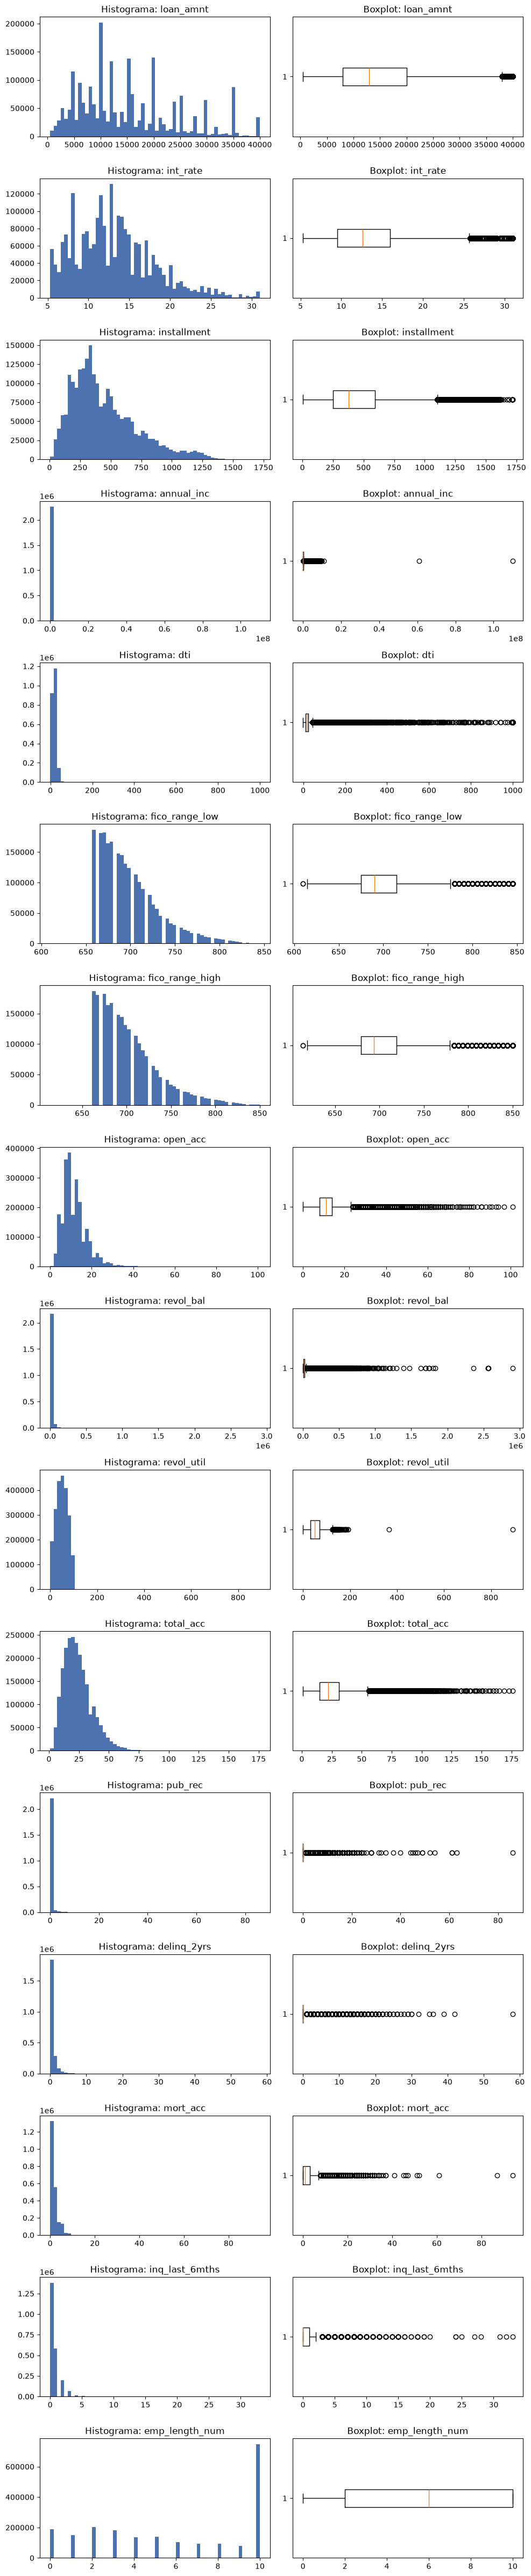

In [12]:
n = len(numeric_vars)
fig, axes = plt.subplots(n, 2, figsize=(10, 3*n))
for i, col in enumerate(numeric_vars):
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    axes[i,0].hist(s, bins=60, color="#4C72B0")
    axes[i,0].set_title(f"Histograma: {col}")
    axes[i,1].boxplot(s, orientation="horizontal")
    axes[i,1].set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/numeric_hist_box.png", dpi=100)
plt.show()


### 1.2.3 Variables categóricas

In [13]:
cat_vars = ["term","grade","sub_grade","home_ownership","verification_status",
            "purpose","addr_state","initial_list_status","application_type","emp_length"]

summary_rows = []
for col in cat_vars:
    vc = df[col].value_counts(dropna=False)
    vc_pct = (vc/len(df)*100).round(2)
    summary_rows.append({
        "variable": col, "n_categorias": df[col].nunique(dropna=True),
        "n_categorias_raras(<1%)": (vc_pct<1).sum(),
        "pct_missing": round(df[col].isna().mean()*100,2),
        "categoria_mas_frecuente": vc.index[0], "pct_mas_frecuente": vc_pct.iloc[0]
    })
cat_summary = pd.DataFrame(summary_rows).set_index("variable")
cat_summary.to_csv("../outputs/tables/eda/categorical_summary.csv")
cat_summary


,n_categorias,n_categorias_raras(<1%),pct_missing,categoria_mas_frecuente,pct_mas_frecuente
variable,,,,,
term,2,1,0.0,36 months,71.21
grade,7,2,0.0,B,29.35
sub_grade,35,11,0.0,C1,6.45
home_ownership,6,4,0.0,MORTGAGE,49.16
verification_status,3,1,0.0,Source Verified,39.20
purpose,14,7,0.0,debt_consolidation,56.53
addr_state,51,24,0.0,CA,13.91
initial_list_status,2,1,0.0,w,67.92
application_type,2,1,0.0,Individual,94.66


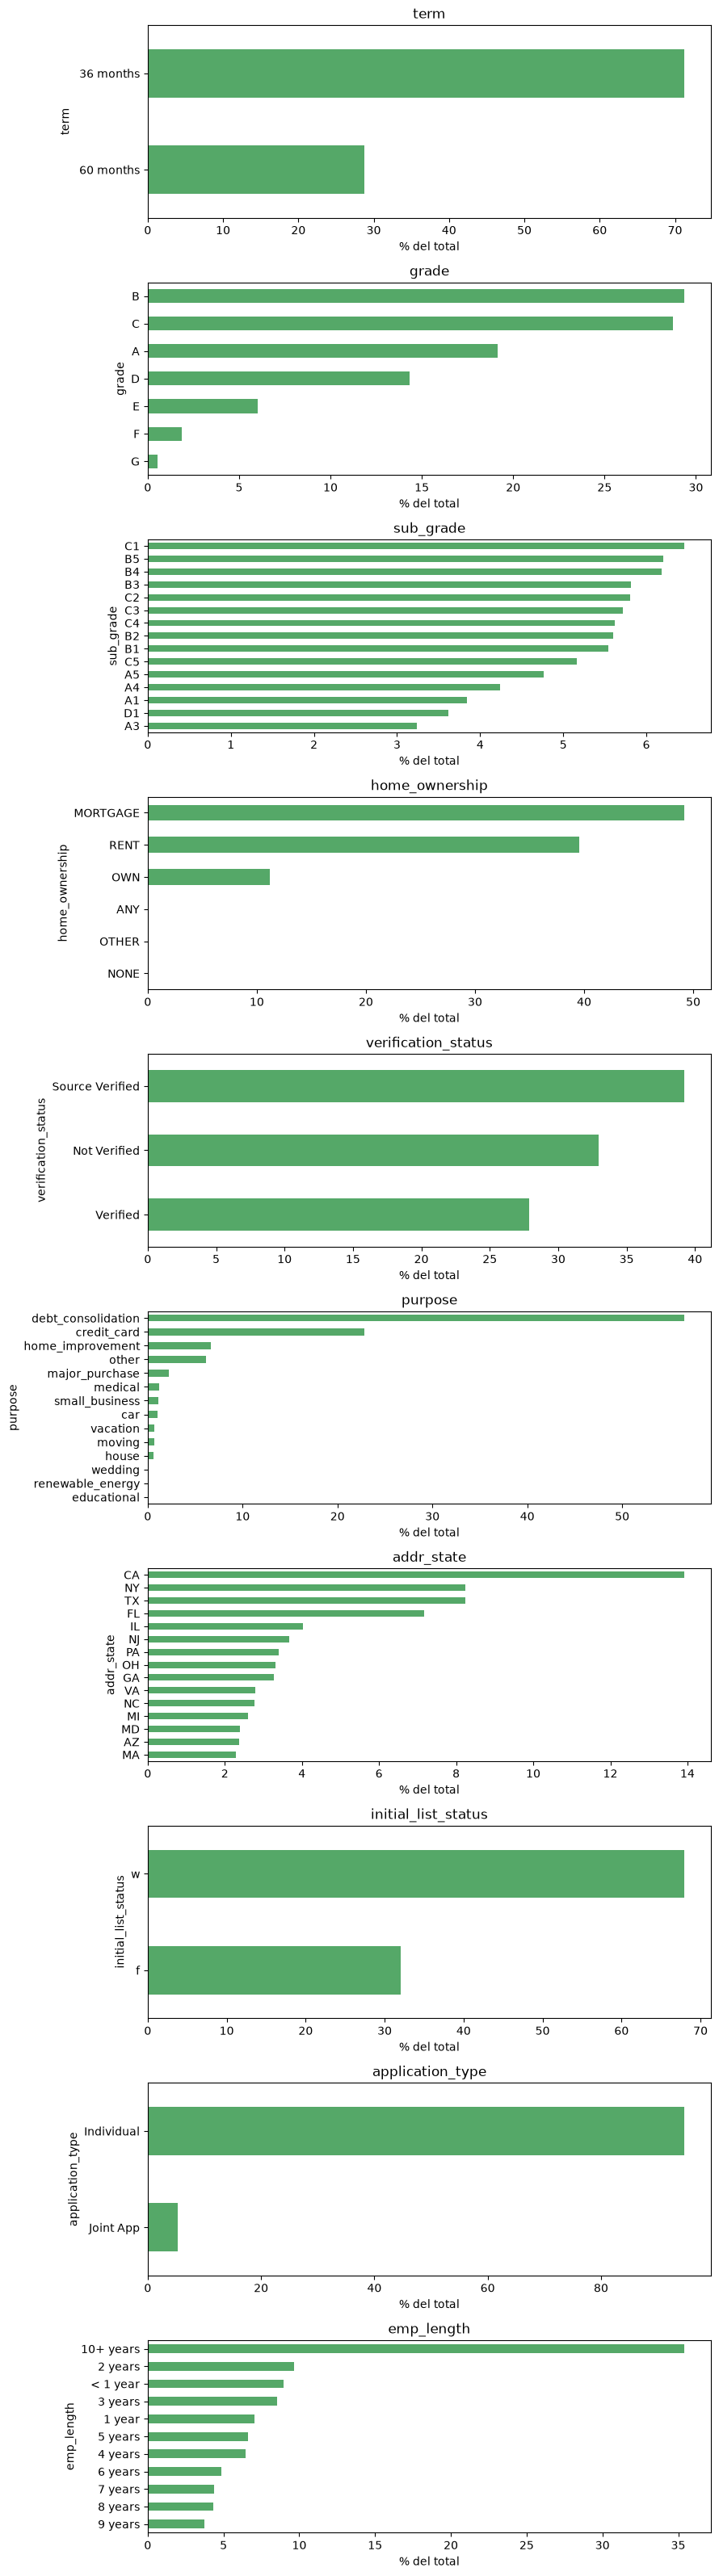

In [14]:
fig, axes = plt.subplots(len(cat_vars), 1, figsize=(9, 3.2*len(cat_vars)))
for i, col in enumerate(cat_vars):
    top = (df[col].value_counts(normalize=True)*100).head(15)
    top.plot(kind="barh", ax=axes[i], color="#55A868")
    axes[i].invert_yaxis()
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("% del total")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/categorical_bars.png", dpi=100)
plt.show()


Al revisar las variables categóricas también encontramos algunas diferencias importantes en la cantidad de categorías. Por ejemplo, **`addr_state`** tiene 51 categorías y 23 de ellas representan menos del 1% de los datos cada una. Si utilizamos one-hot encoding, esto puede hacer que el número de variables aumente bastante sin aportar necesariamente mucha información al modelo.

Por eso, una opción que consideramos es agrupar las categorías con muy pocos registros en una sola categoría llamada “Otros”. De esta forma podemos reducir un poco la cantidad de variables sin perder demasiada información.

Algo parecido ocurre con **`sub_grade`**, que tiene 35 categorías, y con **`purpose`**, que tiene 14. En este último caso, 7 categorías tienen muy pocos registros. Aunque el problema es menor que en **`addr_state`**, también es algo que debemos tener en cuenta al momento de preparar las variables para los modelos.

## 1.3. Análisis bidimensional

### 1.3.1 Numéricas vs. `default`

In [15]:
rows = []
for col in numeric_vars:
    s = pd.to_numeric(df[col], errors="coerce")
    valid = s.notna()
    g0 = s[valid & (df["default"]==0)]
    g1 = s[valid & (df["default"]==1)]
    stat_mw, p_mw = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    r_pb, p_pb = stats.pointbiserialr(df.loc[valid,"default"], s[valid])
    rows.append({"variable": col, "media_0": g0.mean(), "media_1": g1.mean(),
                 "diff_medias": g1.mean()-g0.mean(), "mannwhitney_p": p_mw,
                 "point_biserial_r": round(r_pb,4)})
num_vs_target = pd.DataFrame(rows).set_index("variable")
num_vs_target.to_csv("../outputs/tables/eda/numeric_vs_target.csv")
num_vs_target.round(4)


,media_0,media_1,diff_medias,mannwhitney_p,point_biserial_r
variable,,,,,
loan_amnt,14977.0822,15565.0554,587.9733,0.0,0.0207
int_rate,12.7399,15.7107,2.9708,0.0,0.1989
installment,443.1994,465.1480,21.9486,0.0,0.0266
annual_inc,79015.8765,70400.7433,-8615.1332,0.0,-0.0247
dti,18.6425,20.1712,1.5287,0.0,0.0349
fico_range_low,700.0358,687.8501,-12.1857,0.0,-0.1194
fico_range_high,704.0360,691.8502,-12.1859,0.0,-0.1194
open_acc,11.5735,11.9013,0.3278,0.0,0.0188
revol_bal,16834.3812,15353.5006,-1480.8807,0.0,-0.0209


Al comparar las variables numéricas entre los préstamos que terminaron en **`default`** y los que no, encontramos lo siguiente:

- Todas las variables presentan diferencias estadísticamente significativas según la prueba de Mann-Whitney. Sin embargo, con 2,26 millones de observaciones, un p-valor cercano a 0 no necesariamente significa que la diferencia sea importante en la práctica.
- Por eso, en lugar de fijarnos solamente en el p-valor, también revisamos la correlación punto-biserial para tener una idea de qué tan fuerte es la relación de cada variable con **`default`**.
- **`int_rate`** es la variable que presenta la relación más fuerte, con una correlación de **0,199**.
- Le siguen **`fico_range_low`** y **`fico_range_high`**, con correlaciones cercanas a **-0,119**, y **`inq_last_6mths`**, con una correlación de **0,083**.
- El resto de las variables tiene correlaciones bastante débiles, con valores absolutos menores a **0,05**.
- Esto tiene sentido para un problema de riesgo crediticio, ya que no esperamos que una sola variable sea suficiente para predecir el incumplimiento. Lo importante es que el modelo pueda combinar varias variables y encontrar patrones entre ellas.
- Finalmente, en los boxplots recortamos los valores por encima del percentil 99 únicamente para que las gráficas fueran más fáciles de leer. Este recorte se hizo solo para visualizar los datos, los estadísticos y resultados de las pruebas se calcularon utilizando el conjunto completo.

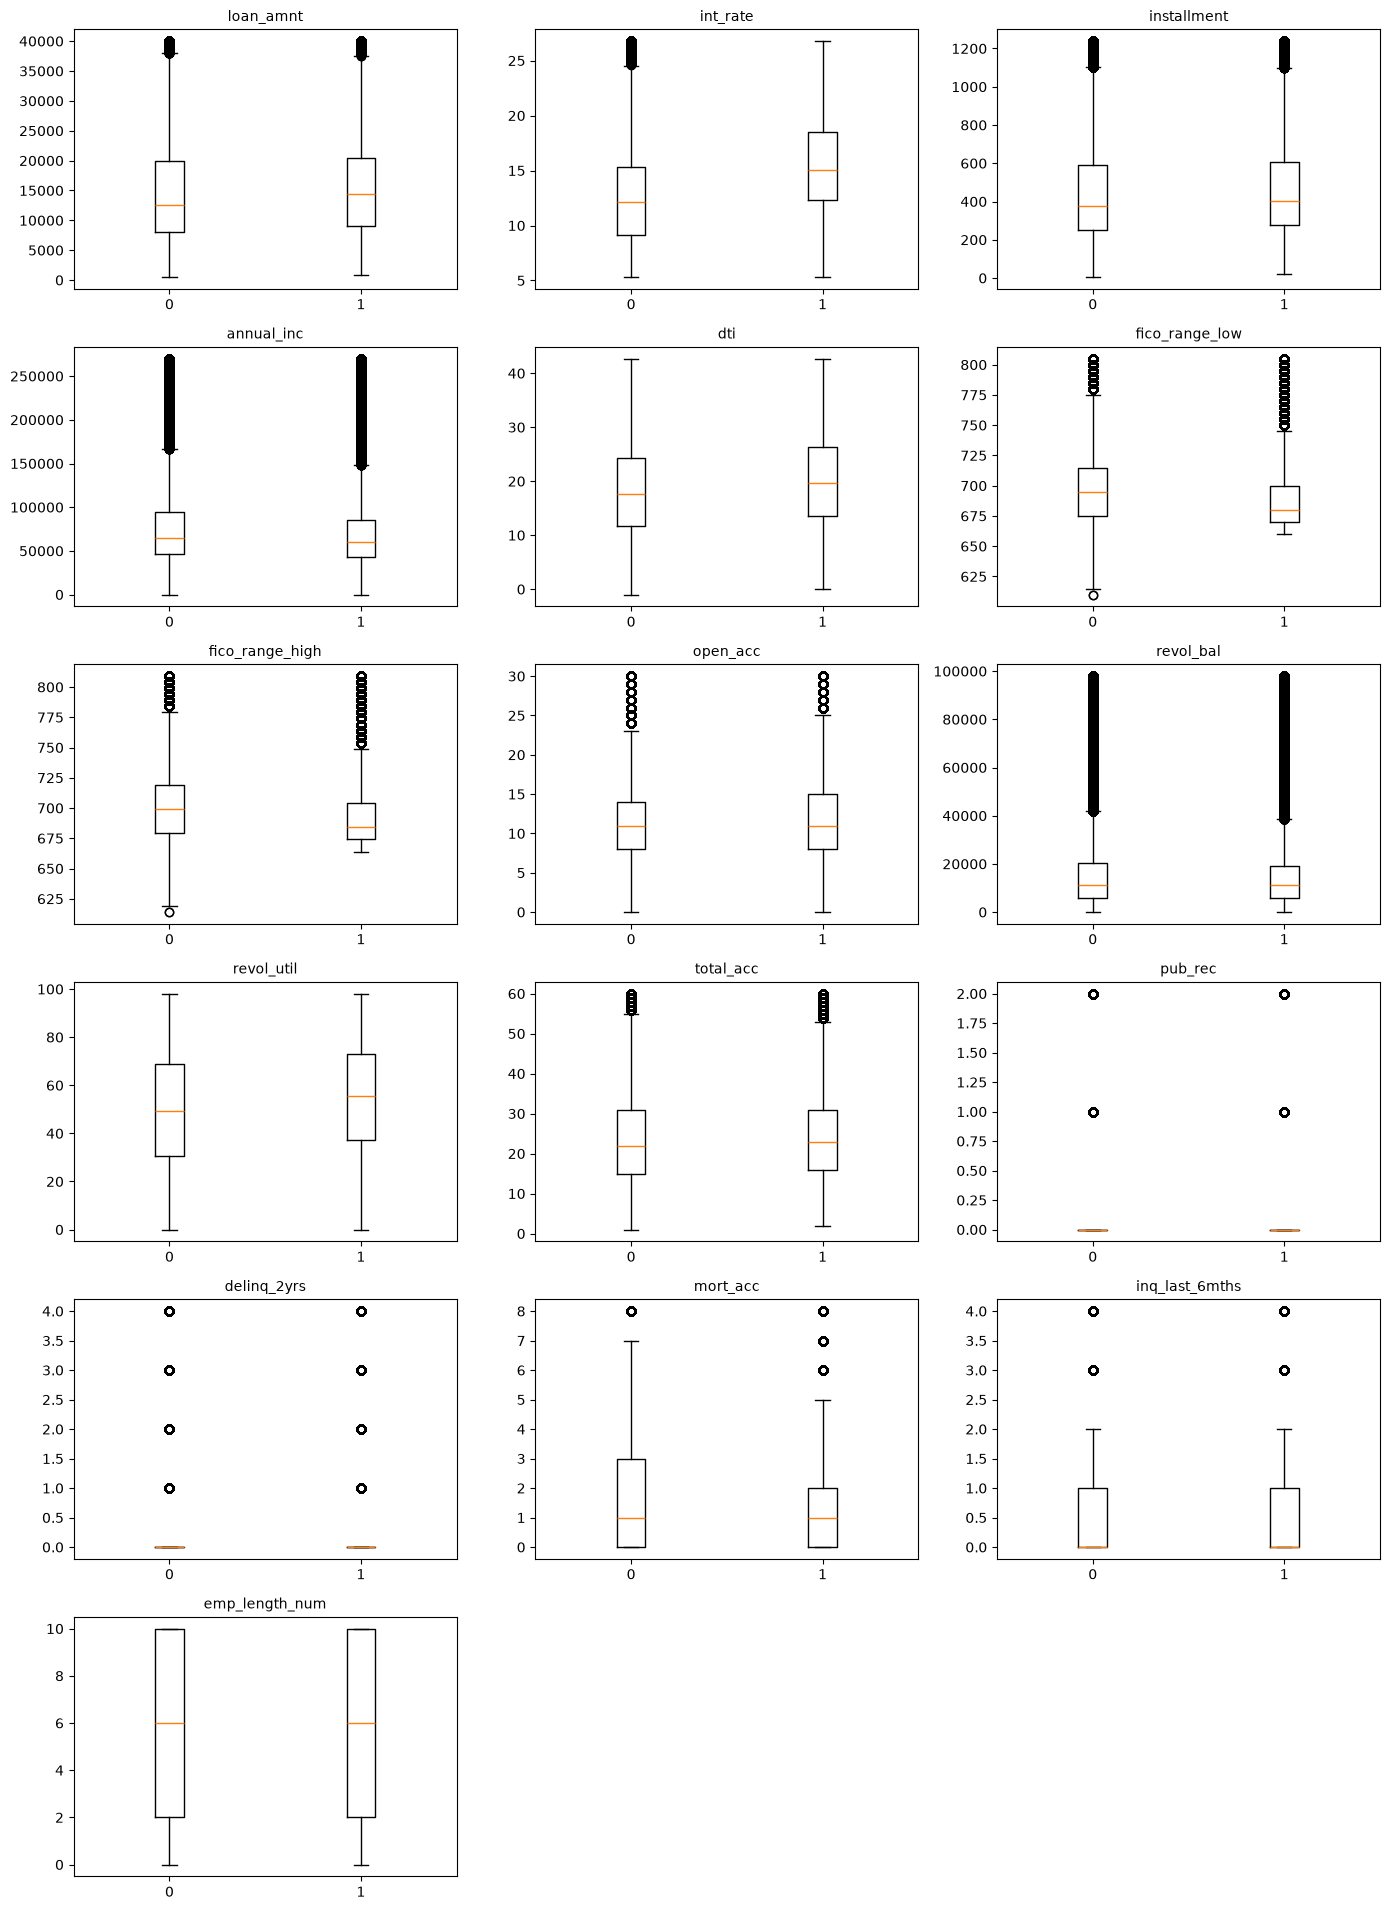

In [16]:
n = len(numeric_vars)
fig, axes = plt.subplots((n+2)//3, 3, figsize=(14, 3.2*((n+2)//3)))
axes = axes.flatten()
for i, col in enumerate(numeric_vars):
    s = pd.to_numeric(df[col], errors="coerce")
    cap = s.quantile(0.99)
    data0 = s[df["default"]==0].dropna().clip(upper=cap)
    data1 = s[df["default"]==1].dropna().clip(upper=cap)
    axes[i].boxplot([data0, data1], tick_labels=["0","1"])
    axes[i].set_title(col, fontsize=10)
for j in range(i+1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/boxplots_by_class.png", dpi=100)
plt.show()


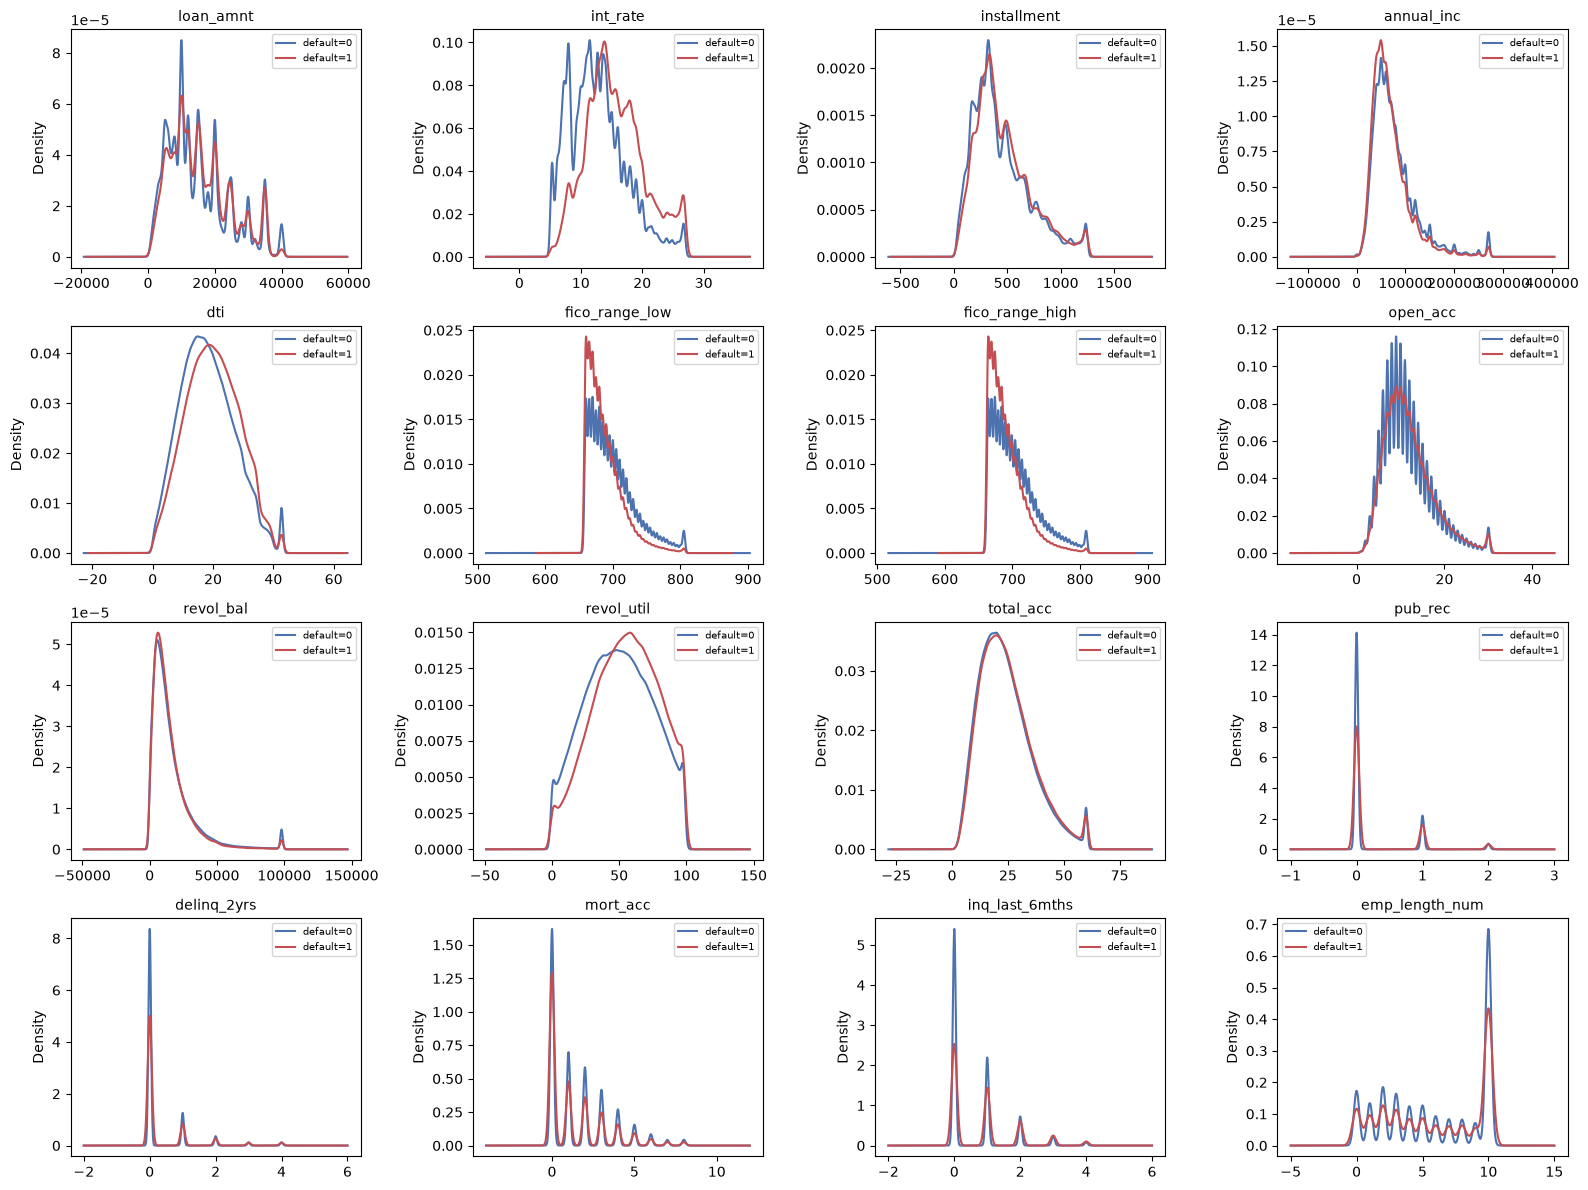

In [17]:
fig, axes = plt.subplots(4, 4, figsize=(16,12))
axes = axes.flatten()
for i, col in enumerate(numeric_vars):
    s = pd.to_numeric(df[col], errors="coerce")
    cap = s.quantile(0.99)
    for cls, color in [(0,"#4C72B0"), (1,"#C44E52")]:
        data = s[df["default"]==cls].dropna().clip(upper=cap)
        data.plot(kind="density", ax=axes[i], color=color, label=f"default={cls}")
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)
plt.tight_layout()
plt.savefig("../outputs/figures/eda/kde_by_class.png", dpi=100)
plt.show()


### 1.3.2 Categóricas vs. `default`

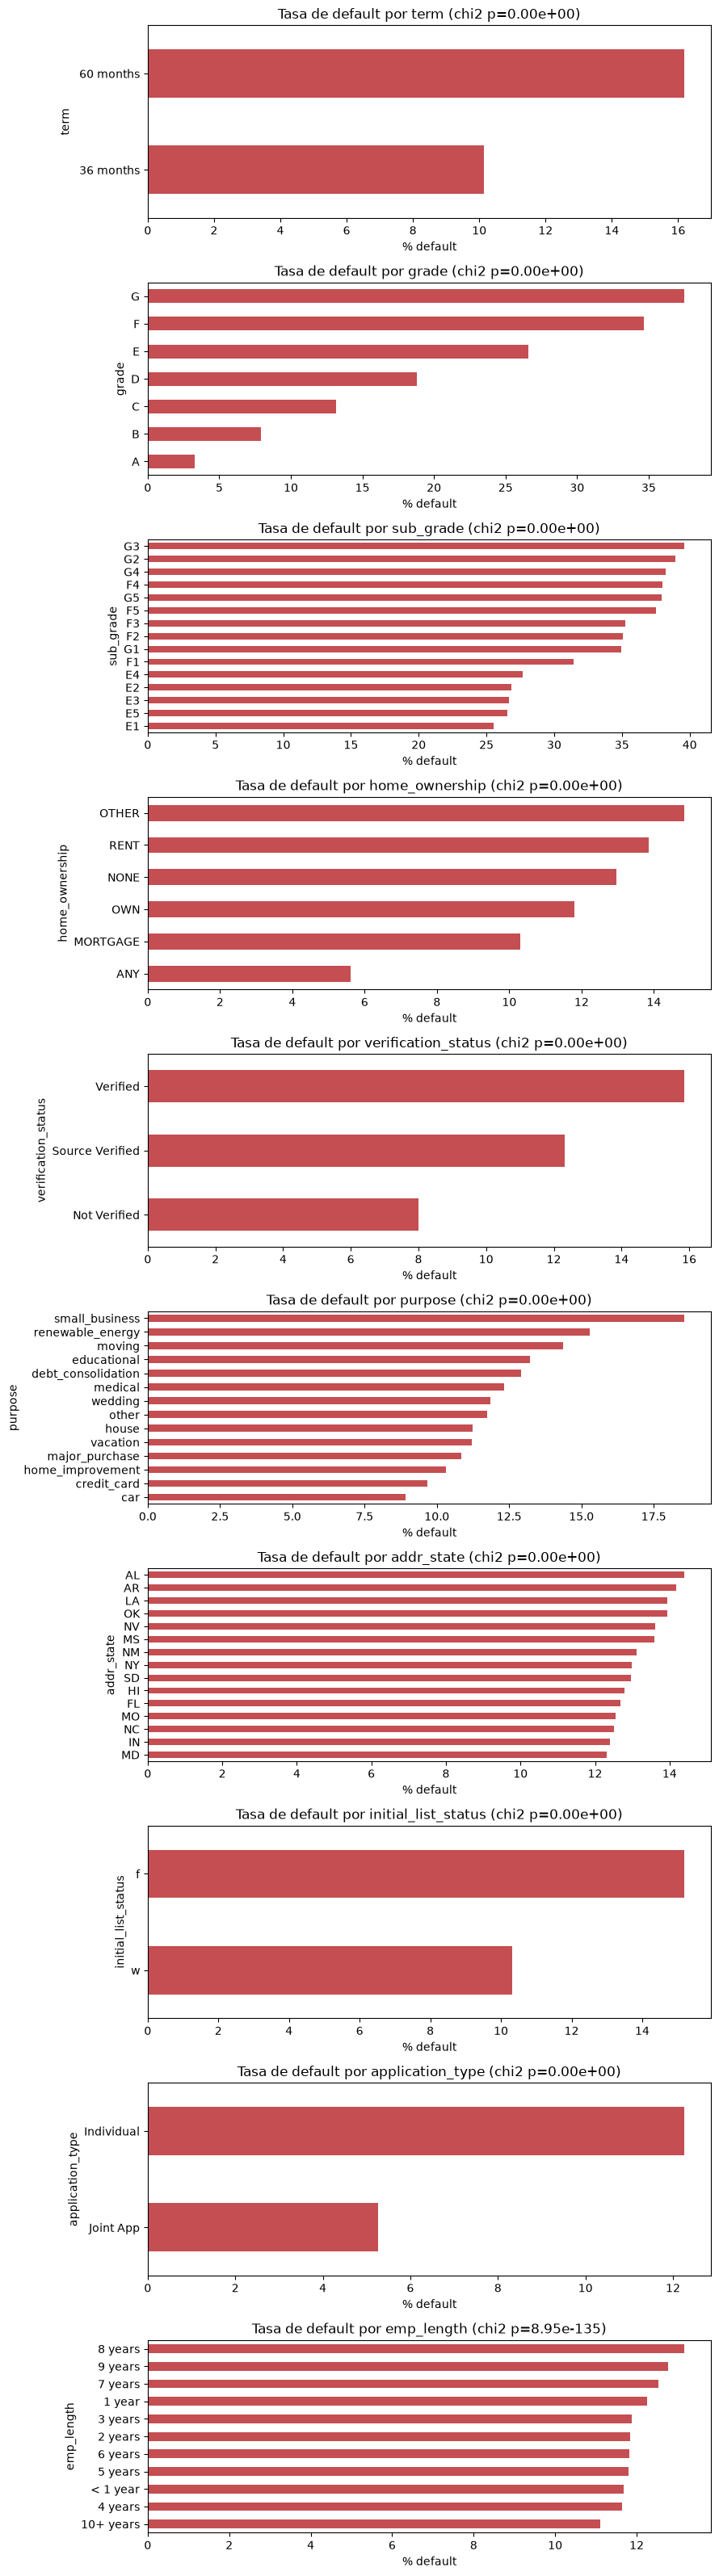

,chi2,p_value,dof,categoria_mayor_default_%,tasa_mayor_default_%,categoria_menor_default_%,tasa_menor_default_%
variable,,,,,,,
term,16135.405611,0.000000e+00,1,60 months,16.18,36 months,10.14
grade,112789.264671,0.000000e+00,6,G,37.48,A,3.28
sub_grade,116768.427893,0.000000e+00,34,G3,39.59,A1,1.62
home_ownership,6040.699202,0.000000e+00,5,OTHER,14.84,ANY,5.62
verification_status,20391.761668,0.000000e+00,2,Verified,15.85,Not Verified,7.99
purpose,5506.641353,0.000000e+00,13,small_business,18.55,car,8.92
addr_state,3226.072554,0.000000e+00,50,AL,14.39,ME,5.65
initial_list_status,11140.302534,0.000000e+00,1,f,15.18,w,10.32
application_type,5344.285224,0.000000e+00,1,Individual,12.25,Joint App,5.26


In [18]:
chi2_rows = []
fig, axes = plt.subplots(len(cat_vars), 1, figsize=(9, 3.2*len(cat_vars)))
for i, col in enumerate(cat_vars):
    ct = pd.crosstab(df[col], df["default"])
    chi2, p, dof, exp = chi2_contingency(ct)
    default_rate = (df.groupby(col, observed=True)["default"].mean()*100).sort_values(ascending=False)
    chi2_rows.append({"variable": col, "chi2": chi2, "p_value": p, "dof": dof,
                       "categoria_mayor_default_%": default_rate.index[0],
                       "tasa_mayor_default_%": round(default_rate.iloc[0],2),
                       "categoria_menor_default_%": default_rate.index[-1],
                       "tasa_menor_default_%": round(default_rate.iloc[-1],2)})
    default_rate.head(15).plot(kind="barh", ax=axes[i], color="#C44E52")
    axes[i].invert_yaxis()
    axes[i].set_title(f"Tasa de default por {col} (chi2 p={p:.2e})")
    axes[i].set_xlabel("% default")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/default_rate_by_category.png", dpi=100)
plt.show()

cat_vs_target = pd.DataFrame(chi2_rows).set_index("variable")
cat_vs_target.to_csv("../outputs/tables/eda/categorical_vs_target.csv")
cat_vs_target


`grade` y `sub_grade` muestran el patrón más claro de todos: la tasa de default sube de 3,3% en grado A a 37,5% en grado G, de forma bastante escalonada. Esto tiene sentido porque el grade de Lending Club ya es en sí mismo una especie de puntaje de riesgo que la plataforma le asigna a cada préstamo. También encontramos que el plazo (`term`) de 60 meses casi duplica la tasa de default del de 36 meses (16,2% contra 10,1%). Todas estas variables categóricas resultaron significativas en la prueba de chi-cuadrado, pero lo más importante es que las diferencias en la tasa de default son grandes para `grade`, `sub_grade` y `term`, no solo estadísticamente significativas.

### 1.3.3 Multicolinealidad

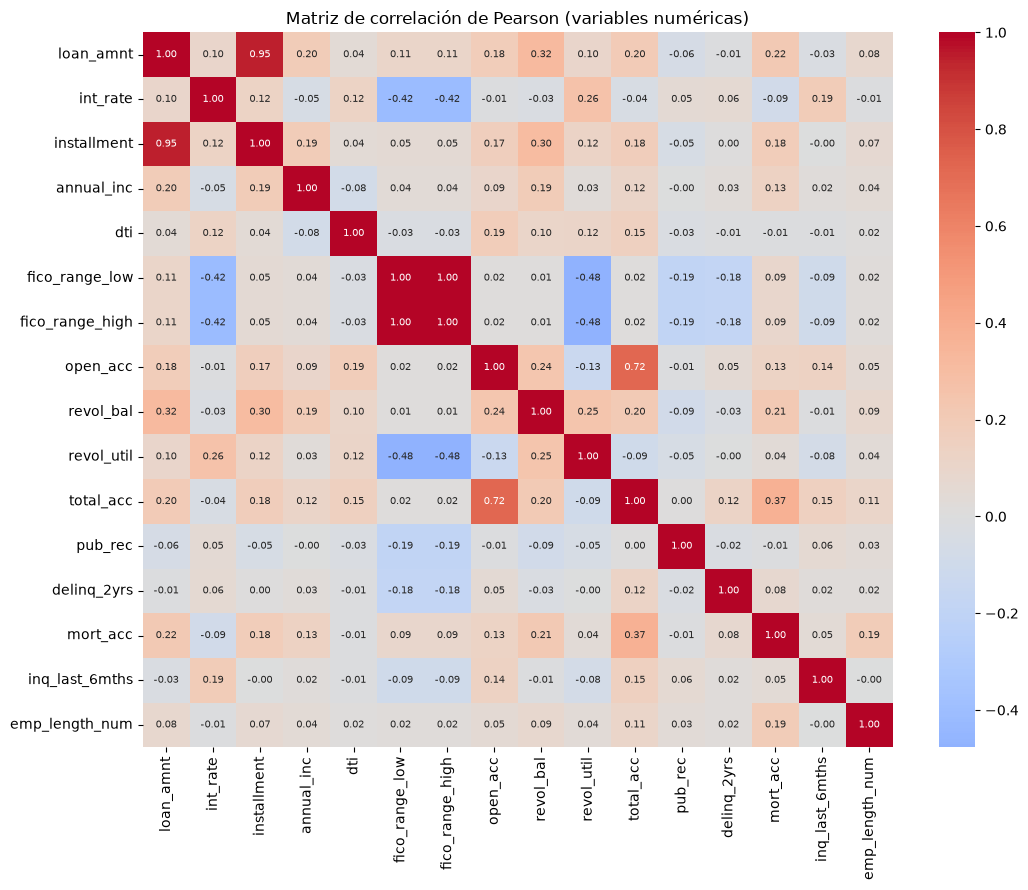

Pares con |r| > 0.7:
  loan_amnt -- installment: r=0.946
  fico_range_low -- fico_range_high: r=1.0
  open_acc -- total_acc: r=0.718

int_rate -- fico_range_high: r=-0.416 (moderada, no supera 0.7)


In [19]:
corr = df[numeric_vars].apply(pd.to_numeric, errors="coerce").corr(method="pearson")
corr.to_csv("../outputs/tables/eda/correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(11,9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, annot_kws={"size":7})
ax.set_title("Matriz de correlación de Pearson (variables numéricas)")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/correlation_heatmap.png", dpi=110)
plt.show()

high_corr = [(corr.columns[i], corr.columns[j], round(corr.iloc[i,j],3))
             for i in range(len(corr.columns)) for j in range(i+1, len(corr.columns))
             if abs(corr.iloc[i,j]) > 0.7]
print("Pares con |r| > 0.7:")
for a,b,r in high_corr:
    print(f"  {a} -- {b}: r={r}")
print(f"\nint_rate -- fico_range_high: r={corr.loc['int_rate','fico_range_high']:.3f} (moderada, no supera 0.7)")


Encontramos tres redundancias bastante claras entre las variables numéricas. La primera es entre `fico_range_low` y `fico_range_high`, con una correlación de 1,00. Esto tiene sentido porque el rango FICO siempre viene en un intervalo de 4 puntos, así que en la práctica es el mismo dato repetido dos veces, y para el modelado basta usar una de las dos. La segunda es entre `loan_amnt` e `installment` (r=0,946), porque la cuota mensual es casi una función matemática del monto, la tasa y el plazo del préstamo, es decir, ya está contenida en `loan_amnt`, `term` e `int_rate` juntas. La tercera es entre `open_acc` y `total_acc` (r=0,718), una redundancia más moderada entre el número de cuentas abiertas y el número total de cuentas que la persona ha tenido.

También revisamos, como lo sugiere el enunciado, la relación entre `int_rate` y `fico_range_high`. La correlación es moderada y negativa (alrededor de -0,4), pero no llega al umbral de 0,7 que consideramos como multicolinealidad fuerte. Esto tiene sentido porque el puntaje FICO es solo uno de los factores que determinan la tasa de interés, junto con el grado, el plazo y el monto del préstamo.

In [20]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt((chi2/n) / min(k-1, r-1))

cramers_rows = []
for i in range(len(cat_vars)):
    for j in range(i+1, len(cat_vars)):
        v = cramers_v(df[cat_vars[i]], df[cat_vars[j]])
        cramers_rows.append({"var1": cat_vars[i], "var2": cat_vars[j], "cramers_v": round(v,3)})
cramers_df = pd.DataFrame(cramers_rows).sort_values("cramers_v", ascending=False)
cramers_df.to_csv("../outputs/tables/eda/cramers_v.csv", index=False)
cramers_df.head(10)


,var1,var2,cramers_v
9,grade,sub_grade,1.000
1,term,sub_grade,0.395
0,term,grade,0.385
18,sub_grade,verification_status,0.190
11,grade,verification_status,0.176
6,term,initial_list_status,0.152
21,sub_grade,initial_list_status,0.143
14,grade,initial_list_status,0.138
26,home_ownership,addr_state,0.113
2,term,home_ownership,0.109


Por último, `grade` y `sub_grade` tienen una V de Cramér de 1,0, lo que significa que `sub_grade` determina `grade` por completo (todas las categorías A1 a A5 son grado A, y así sucesivamente). Son la misma información en distinta granularidad, así que para el modelado decidimos usar solo una de las dos.

## 1.4. Valores faltantes (análisis detallado)

In [21]:
profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean()*100).round(2),
    "n_unique": df.nunique(dropna=True),
}).sort_values("pct_missing", ascending=False)
profile.to_csv("../outputs/tables/column_profile_full.csv")

print(f"Columnas sin nulos: {(profile['pct_missing']==0).sum()}")
print(f"Columnas con >30% nulos: {(profile['pct_missing']>30).sum()}")
print(f"Columnas con >70% nulos: {(profile['pct_missing']>70).sum()}")
profile.head(15)


Columnas sin nulos: 50
Columnas con >30% nulos: 58
Columnas con >70% nulos: 41


,dtype,n_missing,pct_missing,n_unique
member_id,null[pyarrow],2260701,100.00,0
orig_projected_additional_accrued_interest,double[pyarrow],2252050,99.62,7487
payment_plan_start_date,string[pyarrow],2249784,99.52,27
hardship_status,string[pyarrow],2249784,99.52,3
hardship_start_date,string[pyarrow],2249784,99.52,27
hardship_dpd,double[pyarrow],2249784,99.52,34
hardship_loan_status,string[pyarrow],2249784,99.52,5
hardship_length,double[pyarrow],2249784,99.52,1
deferral_term,double[pyarrow],2249784,99.52,1
hardship_payoff_balance_amount,double[pyarrow],2249784,99.52,10893


<Figure size 1600x800 with 0 Axes>

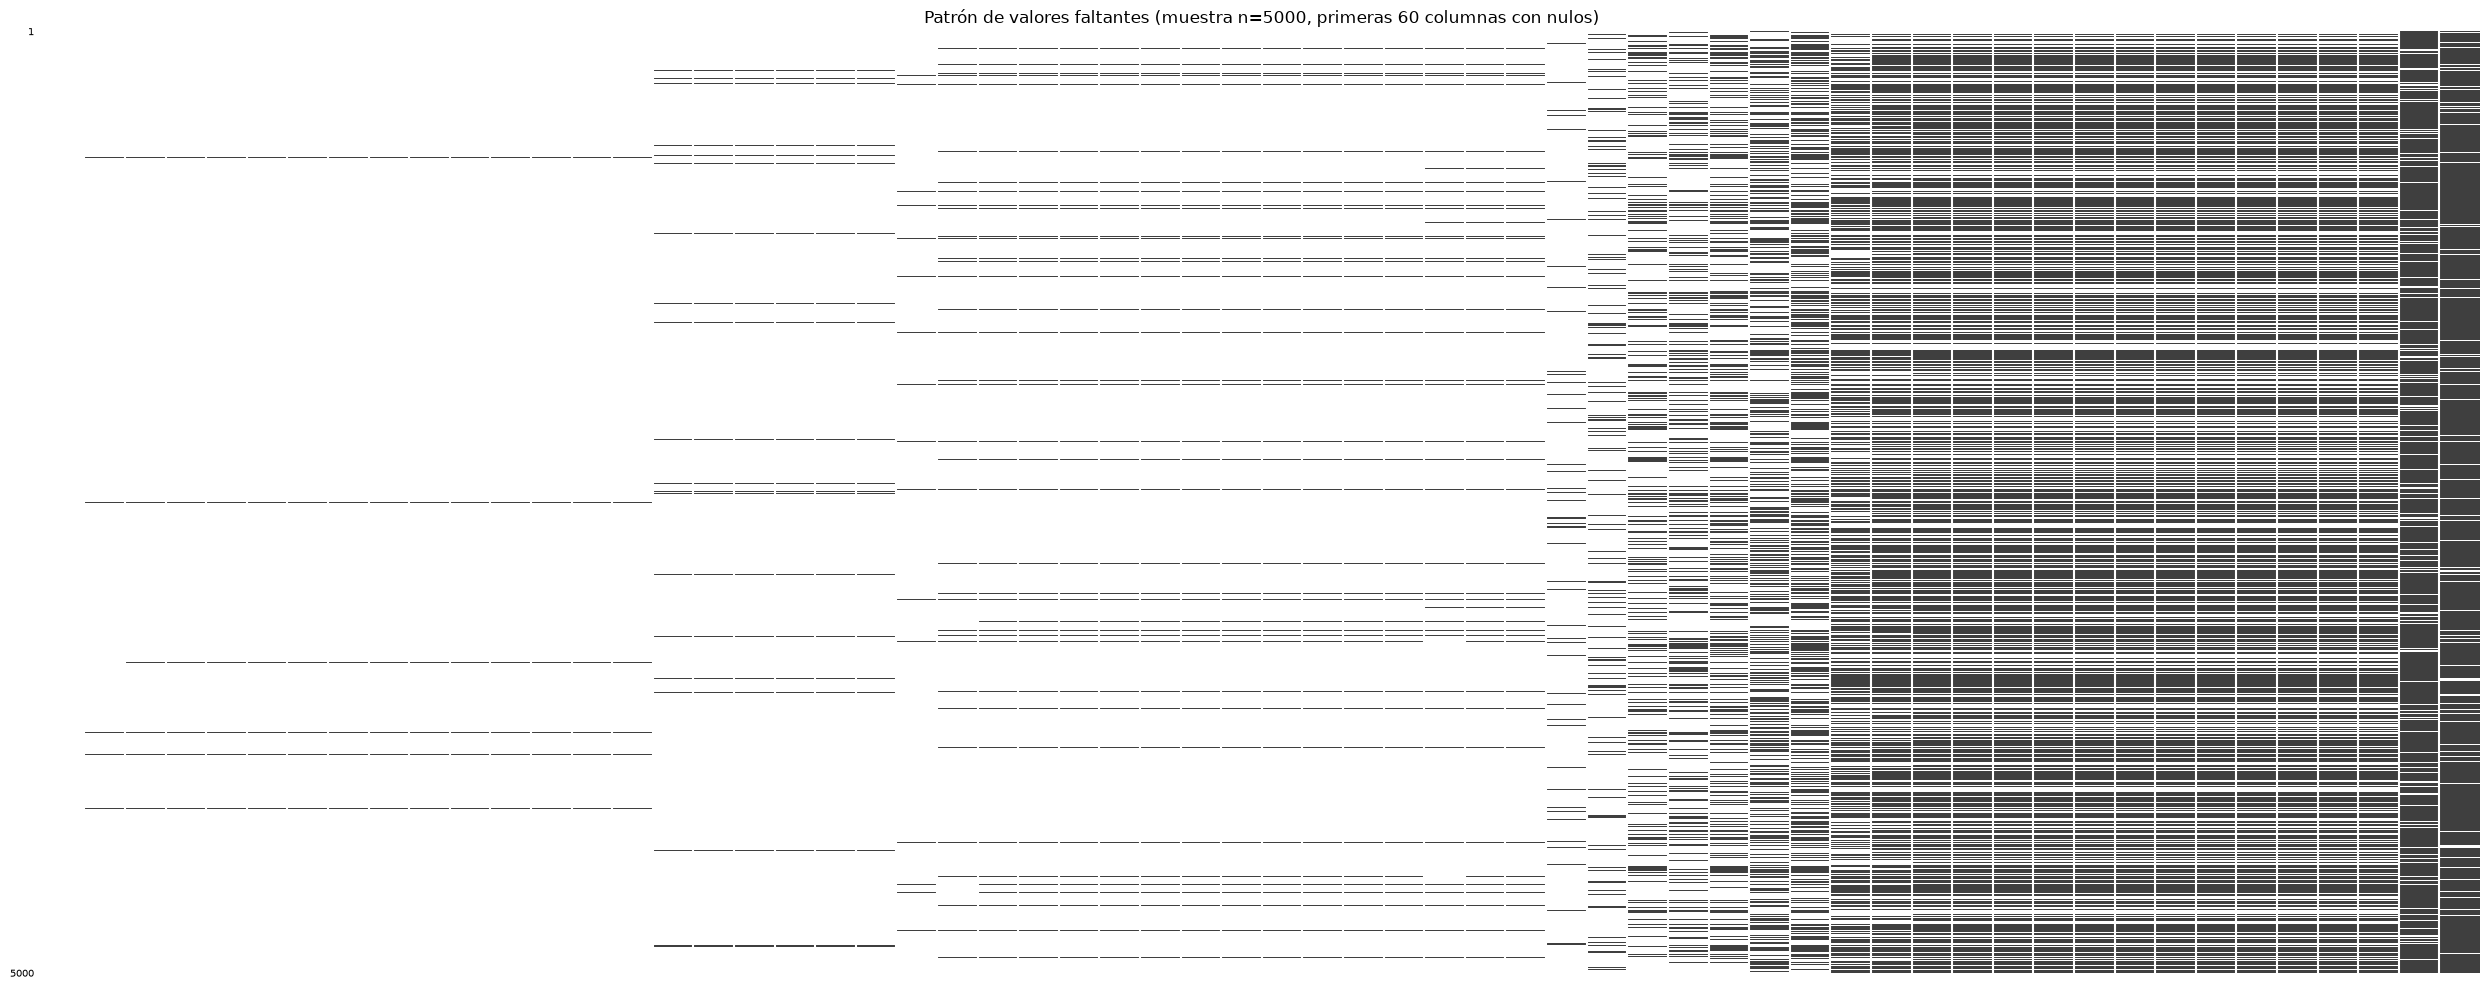

In [22]:
sample = df.sample(5000, random_state=42)
cols_con_nulos = profile[profile["pct_missing"]>0].index.tolist()

fig = plt.figure(figsize=(16,8))
msno.matrix(sample[cols_con_nulos[:60]], sparkline=False, fontsize=6)
plt.title("Patrón de valores faltantes (muestra n=5000, primeras 60 columnas con nulos)")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/missing_matrix.png", dpi=100)
plt.show()


<Figure size 1000x1000 with 0 Axes>

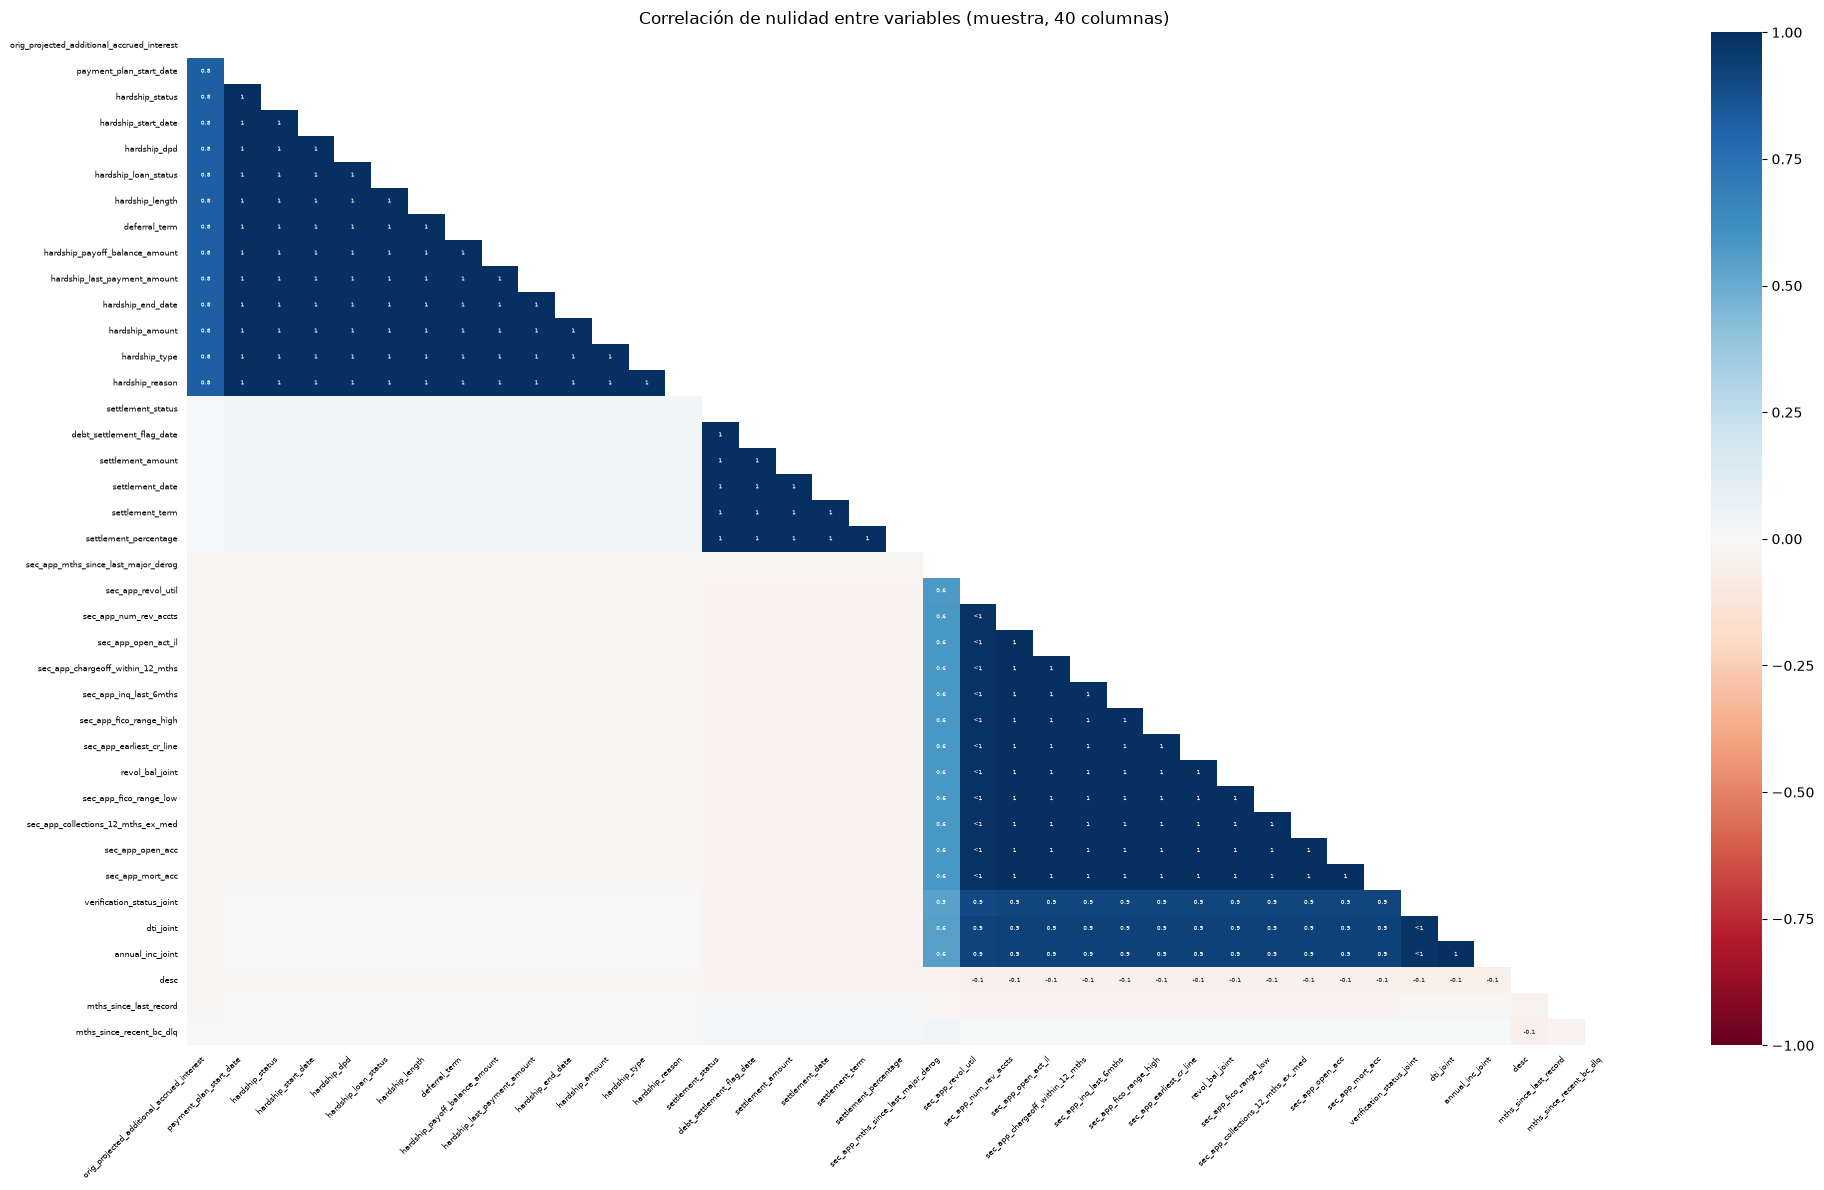

In [23]:
fig = plt.figure(figsize=(10,10))
msno.heatmap(sample[cols_con_nulos[:40]], fontsize=6)
plt.title("Correlación de nulidad entre variables (muestra, 40 columnas)")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/missing_heatmap.png", dpi=100)
plt.show()


In [24]:
rows = []
candidatas = profile[(profile["pct_missing"]>0.5) & (profile["pct_missing"]<99)].index.tolist()
for col in candidatas:
    is_missing = df[col].isna().astype(int)
    if is_missing.nunique() < 2:
        continue
    ct = pd.crosstab(is_missing, df["default"])
    chi2, p, dof, exp = chi2_contingency(ct)
    rows.append({"variable": col, "pct_missing": profile.loc[col,"pct_missing"], "chi2_p": p,
                 "tasa_default_si_falta": round(df.loc[is_missing==1,"default"].mean()*100,2),
                 "tasa_default_si_no_falta": round(df.loc[is_missing==0,"default"].mean()*100,2)})
miss_target = pd.DataFrame(rows).sort_values("chi2_p")
miss_target.to_csv("../outputs/tables/eda/missingness_vs_target.csv", index=False)
print(f"{(miss_target['chi2_p']<0.05).sum()} de {len(candidatas)} variables con faltantes muestran asociación significativa entre 'falta el dato' y default")
miss_target.head(10)


81 de 81 variables con faltantes muestran asociación significativa entre 'falta el dato' y default


,variable,pct_missing,chi2_p,tasa_default_si_falta,tasa_default_si_no_falta
0,settlement_status,98.49,0.0,10.57,97.15
1,debt_settlement_flag_date,98.49,0.0,10.57,97.15
2,settlement_amount,98.49,0.0,10.57,97.15
3,settlement_date,98.49,0.0,10.57,97.15
4,settlement_term,98.49,0.0,10.57,97.15
5,settlement_percentage,98.49,0.0,10.57,97.15
7,sec_app_revol_util,95.30,0.0,12.26,4.21
8,sec_app_num_rev_accts,95.22,0.0,12.26,4.27
12,sec_app_fico_range_high,95.22,0.0,12.26,4.27
9,sec_app_open_act_il,95.22,0.0,12.26,4.27


La ausencia de datos no es aleatoria, y esta fue una de las señales más claras de todo el análisis exploratorio. Encontramos dos patrones bien distintos.

El primero es en `settlement_status` y los campos relacionados, que tienen 98,5% de valores nulos. Cuando ese dato sí existe, la tasa de default es de 97,15%, comparada con solo 10,57% cuando falta. La explicación es sencilla, pero también es una alerta importante de fuga de datos: un registro de acuerdo de pago (settlement) solo se crea después de que el préstamo ya entró en incumplimiento severo, así que es información que viene después del desenlace y no se debería usar como predictor.

El segundo patrón está en los campos `sec_app_*` y los que terminan en `_joint`, con casi 95% de nulos. Estos faltan simplemente porque el préstamo no es una solicitud conjunta, no por ningún error al recolectar los datos. Es un tipo de ausencia estructural, donde el hecho de que falte el dato ya es información en sí misma (nos dice que el préstamo es individual), y además tiene relación real con el riesgo, porque las solicitudes conjuntas tienden a tener menor tasa de default, probablemente porque combinan dos ingresos.

Los dos casos nos mostraron por qué simplemente imputar los valores faltantes sin pensar primero en por qué faltan puede ser un error.

In [25]:
def plan_tratamiento(row):
    if row["pct_missing"] == 0:
        return "sin tratamiento"
    if row["pct_missing"] > 70:
        return "eliminar columna (>70% nulo)"
    if "double" in row["dtype"] or "int" in row["dtype"]:
        return "imputar con mediana (train) + indicador de faltante si aplica"
    return "imputar con moda o categoría 'Desconocido' (train)"

profile["plan_tratamiento"] = profile.apply(plan_tratamiento, axis=1)
profile.to_csv("../outputs/tables/eda/column_profile_con_plan.csv")
profile["plan_tratamiento"].value_counts()


plan_tratamiento
imputar con mediana (train) + indicador de faltante si aplica    56
sin tratamiento                                                  50
eliminar columna (>70% nulo)                                     41
imputar con moda o categoría 'Desconocido' (train)                6
Name: count, dtype: int64

## 1.5. Resumen ejecutivo del EDA

**Calidad de los datos**

- El dataset completo tiene 2.260.701 filas y 151 columnas. De esas columnas, 49 no tienen ningún nulo y 41 tienen más del 70% de valores nulos, así que estas últimas son candidatas a eliminarse directamente.
- La ausencia de datos no es aleatoria: se concentra en los campos de hardship y settlement (que son posteriores al desenlace del préstamo y por lo tanto representan un riesgo de fuga de datos) y en los campos del solicitante secundario (que faltan de forma estructural cuando la solicitud es individual).
- `dti` tiene valores centinela que no son reales (mínimo de -1 y máximo de 999) y que hay que tratar antes de modelar. `annual_inc` tiene al menos un valor extremo (110 millones de dólares) que distorsiona bastante la media.

**Variables más prometedoras para predecir ****`default`**

- `int_rate` es la más fuerte (r≈0,20), seguida de `sub_grade`/`grade` (con un gradiente bastante claro, de 3,3% a 37,5% de tasa de default entre A y G), `fico_range_high`/`low` (r≈-0,12), `term` (60 contra 36 meses) e `inq_last_6mths`.
- Ninguna variable por sí sola tiene mucho poder predictivo. Es un problema donde el modelo necesita combinar varias señales débiles, algo típico en el scoring crediticio.

**Problemas detectados**

- Desbalance de clases moderado-alto (88,1% contra 11,9%, casi 7,4 a 1), así que decidimos usar AUC ROC, F1 y AUC-PR como métricas, y estratificar la partición entre entrenamiento y prueba.
- Redundancia entre variables: `fico_range_low` y `fico_range_high` (r=1,0), `sub_grade` y `grade` (V de Cramér=1,0), `loan_amnt` e `installment` (r=0,95).
- La definición del target también es un problema. La regla literal del enunciado deja 878.317 préstamos \"Current\" (39% del total) etiquetados como \"no default\" aunque todavía no se sabe cómo van a terminar, y también clasifica mal 761 préstamos que en la práctica sí fueron impagos pero no calzan exactamente con el texto \"Charged Off\". Seguimos la regla tal como la pide el enunciado, pero esta es la limitación metodológica más importante de todo el proyecto.

**Decisiones preliminares para el preprocesamiento**

- Decidimos mantener: `loan_amnt`, `int_rate`, `sub_grade` (en vez de `grade`, porque ya la contiene), `emp_length`, `annual_inc`, `home_ownership`, `verification_status`, `purpose`, `dti`, `addr_state`, `term`, `fico_range_high` (descartando `fico_range_low`), `open_acc`, `revol_bal`, `revol_util`, `total_acc`, `pub_rec`, `delinq_2yrs`, `mort_acc`, `inq_last_6mths`, `initial_list_status` y `application_type`.
- Decidimos excluir: todo lo que ocurre después de la originación del préstamo (`total_pymnt`, `recoveries`, `out_prncp`, `last_pymnt_*`, `settlement_*`, `hardship_*`, entre otras, por fuga de datos), texto libre de alta cardinalidad (`desc`, `emp_title`, `title`, `url`), identificadores (`id`, `member_id`), y las columnas con más de 70% de nulos.
- Para el preprocesamiento, vamos a tratar los valores centinela de `dti` (-1 y 999) como faltantes, evaluar una transformación logarítmica para `annual_inc` y `revol_bal` por su asimetría tan fuerte, imputar `emp_length` y las demás variables numéricas usando solo la mediana o la moda del conjunto de entrenamiento, y agrupar las categorías poco frecuentes (menos del 1%) de `addr_state` y `purpose` en una categoría \"Otros\" antes de hacer el one-hot encoding.